# Практическая работа №3: Обработка выборочных данных. Нахождение интервальных оценок параметров распределения. Проверка статистической гипотезы о нормальном распределении

Выполнили студенты гр. 2383 Миненок Алиса и Мордасов Евгений. Вариант №27.

## Цель работы

Получение практических навыков вычисления интервальных статистических оценок параметров распределения выборочных данных и проверки «справедливости» статистических гипотез.



## Основные теоретические положения

#### Интервальные статистические оценки

**Интервальной** называется статистическая оценка, которая задаётся двумя числами — концами интервала, в котором может находиться значение параметра $\Theta$.

**Точностью** $\Theta^*$ статистической оценки параметра $\Theta$ называется значение $\delta$, удовлетворяющее неравенству:

$$\delta > |\Theta^* - \Theta|$$

**Надёжностью (доверительной вероятностью)** оценки $\Theta^*$ называется вероятность $\gamma$, с которой выполняется указанное неравенство:

$$\gamma = P\{\Theta^* - \delta < \Theta < \Theta^* + \delta\}$$

Интервал $(\Theta^* - \delta;\; \Theta^* + \delta)$ называется **доверительным интервалом**.

### Доверительный интервал для математического ожидания при неизвестном СКО

Пусть имеется выборка объёма $N$ значений нормально распределённой случайной величины $X$, значение $\sigma = \sigma(X)$ неизвестно. Вводится случайная величина:

$$t = \frac{\bar{x}_в - a}{S / \sqrt{N}}$$

которая распределена по закону Стьюдента с $k = N - 1$ степенями свободы.

Доверительный интервал для математического ожидания $a$:

$$\left(\bar{x}_в - t_\gamma \frac{S}{\sqrt{N}};\; \bar{x}_в + t_\gamma \frac{S}{\sqrt{N}}\right)$$

где $t_\gamma$ определяется по таблице распределения Стьюдента для заданных $\gamma$ и $N$.

Точность оценки: $\delta = t_\gamma \cdot S / \sqrt{N}$.

#### Доверительный интервал для среднеквадратичного отклонения

Доверительный интервал для СКО $\sigma$:

$$\left(S(1 - q);\; S(1 + q)\right)$$

где $q = \delta / S$ определяется по соответствующей таблице для заданных $\gamma$ и $N$.

#### Критерий Пирсона ($\chi^2$)

Для проверки гипотезы $H_0$ о нормальности распределения вычисляется наблюдаемое значение:

$$\chi^2_{\text{набл}} = \sum_{i=1}^{K} \frac{(n_i - n'_i)^2}{n'_i}$$

где $n_i$ — эмпирические частоты, $n'_i = N \cdot p_i$ — теоретические частоты.

Теоретические вероятности $p_i$ вычисляются через функцию Лапласа $\Phi(z)$:

$$z_i = \frac{x_i - \bar{x}_в}{S}, \quad p_i = \Phi(z_{i+1}) - \Phi(z_i)$$

Число степеней свободы: $k = K - 3$.

Если $\chi^2_{\text{набл}} \leq \chi^2_{\text{крит}}(\alpha, k)$, то гипотеза $H_0$ принимается на уровне значимости $\alpha$.



Таким образом:

$$\chi^2_{\text{набл}} = \sum_{i=1}^{K} \frac{n_i^2}{n'_i} - N$$

## Постановка задачи

Для заданной надежности определить (на основании выборочных данных и результатов выполнения практической работы №2) границы доверительных интервалов для математического ожидания и среднеквадратичного отклонения случайной величины. Проверить гипотезу о нормальном распределении исследуемой случайной величины с помощью критерия Пирсона $χ^2. $Дать содержательную интерпретацию полученным результатам.

## Выполнение работы

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.special import erfc
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv('sample_27.csv')

# Разделяем столбец X,Y на два отдельных столбца
data_split = df.iloc[:, 0].astype(str).str.split(',', expand=True)
# Если данные уже разделены на два столбца
if df.shape[1] == 1:
    vals = df.iloc[:, 0].astype(str).str.split(',', expand=True)
    X_data = vals[0].astype(float).values
    Y_data = vals[1].astype(float).values
else:
    X_data = df.iloc[:, 0].astype(float).values
    Y_data = df.iloc[:, 1].astype(float).values

# Работаем с переменной X
data = X_data
N = len(data)
print(f'Объём выборки: N = {N}')
print(f'Первые 10 значений X: {data[:10]}')

Объём выборки: N = 120
Первые 10 значений X: [35.8   8.05 11.85  8.1  12.35 14.05 30.7  15.75 14.7   9.6 ]


### Выборочные характеристики (из практической работы №2)

In [3]:
# Выборочное среднее
x_mean = np.mean(data)

# Исправленное выборочное СКО (с делением на N-1)
S = np.std(data, ddof=1)

print(f'Выборочное среднее: x_в = {x_mean:.4f}')
print(f'Исправленное выборочное СКО: S = {S:.4f}')
print(f'Объём выборки: N = {N}')

Выборочное среднее: x_в = 20.1412
Исправленное выборочное СКО: S = 10.1611
Объём выборки: N = 120


---
### Пункт 1. Доверительный интервал для математического ожидания при неизвестном СКО

Формула доверительного интервала:

$$\left(\bar{x}_в - t_\gamma \frac{S}{\sqrt{N}};\;\; \bar{x}_в + t_\gamma \frac{S}{\sqrt{N}}\right)$$

Точность оценки:

$$\delta = t_\gamma \cdot \frac{S}{\sqrt{N}}$$

где $t_\gamma$ — квантиль распределения Стьюдента с $k = N - 1$ степенями свободы.

In [4]:
# Доверительные интервалы для МО при gamma = 0.95 и 0.99
gammas_mo = [0.95, 0.99]

print('=' * 70)
print('Доверительные интервалы для математического ожидания (неизвестное СКО)')
print('=' * 70)

for gamma in gammas_mo:
    # Квантиль распределения Стьюдента
    # P(|t| < t_gamma) = gamma => alpha_two_sided = 1 - gamma
    alpha_two = 1 - gamma
    t_gamma = stats.t.ppf(1 - alpha_two / 2, df=N - 1)

    # Точность оценки
    delta = t_gamma * S / np.sqrt(N)

    # Доверительный интервал
    ci_lower = x_mean - delta
    ci_upper = x_mean + delta

    print(f'\ngamma = {gamma}:')
    print(f'  t_gamma (Стьюдент, df={N-1}) = {t_gamma:.4f}')
    print(f'  Точность: delta = t_gamma * S / sqrt(N) = {t_gamma:.4f} * {S:.4f} / sqrt({N}) = {delta:.4f}')
    print(f'  Доверительный интервал: ({ci_lower:.4f}; {ci_upper:.4f})')
    print(f'  Или: {x_mean:.4f} ± {delta:.4f}')

Доверительные интервалы для математического ожидания (неизвестное СКО)

gamma = 0.95:
  t_gamma (Стьюдент, df=119) = 1.9801
  Точность: delta = t_gamma * S / sqrt(N) = 1.9801 * 10.1611 / sqrt(120) = 1.8367
  Доверительный интервал: (18.3046; 21.9779)
  Или: 20.1412 ± 1.8367

gamma = 0.99:
  t_gamma (Стьюдент, df=119) = 2.6178
  Точность: delta = t_gamma * S / sqrt(N) = 2.6178 * 10.1611 / sqrt(120) = 2.4282
  Доверительный интервал: (17.7131; 22.5694)
  Или: 20.1412 ± 2.4282


С увеличением доверительной вероятности $\gamma$ (с 0.95 до 0.99) доверительный интервал расширяется, что вполне закономерно: для большей уверенности в том, что истинное значение математического ожидания попадёт в интервал, необходимо расширить его границы. Точность оценки при этом снижается (значение $\delta$ увеличивается).

---
### Пункт 2. Доверительный интервал для среднеквадратичного отклонения

Доверительный интервал для СКО:

$$\left(S(1-q);\;\; S(1+q)\right)$$

Значение $q$ определяется по таблице для заданных $\gamma$ и $N$.

Для вычисления $q$ используем связь с распределением $\chi^2$: границы доверительного интервала для дисперсии $\sigma^2$ при уровне доверия $\gamma$:

$$\frac{(N-1)S^2}{\chi^2_{(1+\gamma)/2}} < \sigma^2 < \frac{(N-1)S^2}{\chi^2_{(1-\gamma)/2}}$$

Извлекая корень, получаем интервал для $\sigma$.

In [5]:
# Доверительные интервалы для СКО
gammas_sko = [0.95, 0.99]

print('=' * 70)
print('Доверительные интервалы для среднеквадратичного отклонения')
print('=' * 70)

for gamma in gammas_sko:
    alpha = 1 - gamma

    # Квантили распределения хи-квадрат
    chi2_lower = stats.chi2.ppf(alpha / 2, df=N - 1)
    chi2_upper = stats.chi2.ppf(1 - alpha / 2, df=N - 1)

    # Доверительный интервал для sigma
    sigma_lower = S * np.sqrt((N - 1) / chi2_upper)
    sigma_upper = S * np.sqrt((N - 1) / chi2_lower)

    # Вычисление q
    q_lower = 1 - sigma_lower / S  # q такое, что sigma_lower = S(1-q)
    q_upper = sigma_upper / S - 1  # q такое, что sigma_upper = S(1+q)

    # Для симметричной записи через q (приближённо)
    q_approx = (sigma_upper - sigma_lower) / (2 * S)

    print(f'\ngamma = {gamma}:')
    print(f'  chi2_lower (alpha/2={alpha/2}, df={N-1}) = {chi2_lower:.4f}')
    print(f'  chi2_upper (1-alpha/2={1-alpha/2}, df={N-1}) = {chi2_upper:.4f}')
    print(f'  Доверительный интервал для sigma: ({sigma_lower:.4f}; {sigma_upper:.4f})')
    print(f'  В формате S(1-q) ... S(1+q):')
    print(f'    S(1 - {q_lower:.4f}) = {S*(1-q_lower):.4f}')
    print(f'    S(1 + {q_upper:.4f}) = {S*(1+q_upper):.4f}')

Доверительные интервалы для среднеквадратичного отклонения

gamma = 0.95:
  chi2_lower (alpha/2=0.025000000000000022, df=119) = 90.6996
  chi2_upper (1-alpha/2=0.975, df=119) = 151.0844
  Доверительный интервал для sigma: (9.0179; 11.6389)
  В формате S(1-q) ... S(1+q):
    S(1 - 0.1125) = 9.0179
    S(1 + 0.1454) = 11.6389

gamma = 0.99:
  chi2_lower (alpha/2=0.0050000000000000044, df=119) = 83.0182
  chi2_upper (1-alpha/2=0.995, df=119) = 162.4815
  Доверительный интервал для sigma: (8.6958; 12.1654)
  В формате S(1-q) ... S(1+q):
    S(1 - 0.1442) = 8.6958
    S(1 + 0.1973) = 12.1654


Аналогично доверительному интервалу для математического ожидания, при увеличении надёжности $\gamma$ доверительный интервал для СКО расширяется. Это означает, что для более высокой уверенности в накрытии истинного значения $\sigma$ требуется более широкий интервал.

---
### Пункт 3. Проверка гипотезы о нормальности распределения (критерий $\chi^2$ Пирсона)

**Гипотеза $H_0$**: выборочные данные представляют значения случайной величины, распределённой по нормальному закону.

**Уровень значимости**: $\alpha = 0.05$.

In [6]:
# --- Построение интервального ряда ---
# Используем формулу Стёрджеса для числа интервалов
K = int(1 + 3.322 * np.log10(N))
print(f'Число интервалов по формуле Стёрджеса: K = 1 + 3.322 * log10({N}) = {K}')

x_min = np.min(data)
x_max = np.max(data)
h = (x_max - x_min) / K  # Ширина интервала
print(f'x_min = {x_min}, x_max = {x_max}')
print(f'Ширина интервала: h = ({x_max} - {x_min}) / {K} = {h:.4f}')

# Границы интервалов
edges = [x_min + i * h for i in range(K + 1)]
# Небольшая корректировка правого края для включения максимума
edges[-1] = x_max + 0.01

# Подсчёт частот попадания в интервалы
n_i = []
for j in range(K):
    count = np.sum((data >= edges[j]) & (data < edges[j + 1]))
    n_i.append(int(count))

n_i = np.array(n_i)
print(f'\nЭмпирические частоты n_i: {n_i}')
print(f'Сумма n_i = {np.sum(n_i)} (должно быть {N})')

Число интервалов по формуле Стёрджеса: K = 1 + 3.322 * log10(120) = 7
x_min = 3.35, x_max = 35.8
Ширина интервала: h = (35.8 - 3.35) / 7 = 4.6357

Эмпирические частоты n_i: [17 20 16 20  8  9 30]
Сумма n_i = 120 (должно быть 120)


In [7]:
# --- Вычисление теоретических частот ---
# Функция Лапласа: Phi(z) = (1/sqrt(2*pi)) * integral(0, z) exp(-t^2/2) dt
# Связь с функцией нормального распределения: Phi_laplace(z) = Phi_norm(z) - 0.5

def laplace_function(z):
    """Функция Лапласа Ф(z) = Ф_0(z) из лекции.
    Phi(z) = (1/sqrt(2*pi)) * integral(0, z) exp(-t^2/2) dt
    Связь: Phi_laplace(z) = stats.norm.cdf(z) - 0.5
    """
    return stats.norm.cdf(z) - 0.5

# Вычисление z_i и теоретических вероятностей p_i
z_values = [(edges[j] - x_mean) / S for j in range(K + 1)]

# Для крайних интервалов: первый от -inf, последний до +inf
phi_values = []
for z in z_values:
    phi_values.append(laplace_function(z))

# Теоретические вероятности
p_i = []
for j in range(K):
    if j == 0:
        # Первый интервал: от -inf до z_1
        p = laplace_function(z_values[1]) - (-0.5)  # Phi(z_1) - Phi(-inf) = Phi(z_1) + 0.5
    elif j == K - 1:
        # Последний интервал: от z_{K-1} до +inf
        p = 0.5 - laplace_function(z_values[K - 1])  # Phi(+inf) - Phi(z_{K-1}) = 0.5 - Phi(z_{K-1})
    else:
        p = laplace_function(z_values[j + 1]) - laplace_function(z_values[j])
    p_i.append(p)

p_i = np.array(p_i)

# Теоретические частоты
n_prime_i = N * p_i

print('Таблица вычисления теоретических частот:')
print(f'{"i":>3} | {"[x_i, x_{i+1})":>18} | {"z_i":>8} | {"z_{i+1}":>8} | {"Ф(z_i)":>8} | {"Ф(z_{i+1})":>10} | {"p_i":>8} | {"n\'_i":>8}')
print('-' * 100)
for j in range(K):
    z_left = '-inf' if j == 0 else f'{z_values[j]:.4f}'
    z_right = '+inf' if j == K - 1 else f'{z_values[j+1]:.4f}'
    phi_left = '-0.5000' if j == 0 else f'{laplace_function(z_values[j]):.4f}'
    phi_right = '0.5000' if j == K - 1 else f'{laplace_function(z_values[j+1]):.4f}'
    print(f'{j+1:>3} | [{edges[j]:>7.2f}, {edges[j+1]:>7.2f}) | {z_left:>8} | {z_right:>8} | {phi_left:>8} | {phi_right:>10} | {p_i[j]:>8.4f} | {n_prime_i[j]:>8.4f}')
print('-' * 100)
print(f'Сумма p_i = {np.sum(p_i):.6f}')
print(f'Сумма n\'_i = {np.sum(n_prime_i):.4f}')

Таблица вычисления теоретических частот:
  i |     [x_i, x_{i+1}) |      z_i |  z_{i+1} |   Ф(z_i) | Ф(z_{i+1}) |      p_i |     n'_i
----------------------------------------------------------------------------------------------------
  1 | [   3.35,    7.99) |     -inf |  -1.1963 |  -0.5000 |    -0.3842 |   0.1158 |  13.8951
  2 | [   7.99,   12.62) |  -1.1963 |  -0.7401 |  -0.3842 |    -0.2704 |   0.1138 |  13.6606
  3 | [  12.62,   17.26) |  -0.7401 |  -0.2838 |  -0.2704 |    -0.1117 |   0.1586 |  19.0363
  4 | [  17.26,   21.89) |  -0.2838 |   0.1724 |  -0.1117 |     0.0684 |   0.1802 |  21.6198
  5 | [  21.89,   26.53) |   0.1724 |   0.6286 |   0.0684 |     0.2352 |   0.1668 |  20.0117
  6 | [  26.53,   31.16) |   0.6286 |   1.0848 |   0.2352 |     0.3610 |   0.1258 |  15.0966
  7 | [  31.16,   35.81) |   1.0848 |     +inf |   0.3610 |     0.5000 |   0.1390 |  16.6798
----------------------------------------------------------------------------------------------------
Сумма p_i = 1

In [8]:
# --- Объединение интервалов с малыми теоретическими частотами (n'_i < 5) ---
# Для корректности критерия хи-квадрат рекомендуется n'_i >= 5

# Создаём копии массивов для объединения
n_merged = list(n_i.copy())
np_merged = list(n_prime_i.copy())
edges_merged = list(edges.copy())

# Объединяем слева
while len(np_merged) > 1 and np_merged[0] < 5:
    n_merged[1] = n_merged[0] + n_merged[1]
    np_merged[1] = np_merged[0] + np_merged[1]
    del n_merged[0], np_merged[0], edges_merged[1]

# Объединяем справа
while len(np_merged) > 1 and np_merged[-1] < 5:
    n_merged[-2] = n_merged[-2] + n_merged[-1]
    np_merged[-2] = np_merged[-2] + np_merged[-1]
    del n_merged[-1], np_merged[-1], edges_merged[-2]

# Объединяем внутренние интервалы, если необходимо
i = 0
while i < len(np_merged):
    if np_merged[i] < 5 and len(np_merged) > 1:
        if i < len(np_merged) - 1:
            n_merged[i+1] = n_merged[i] + n_merged[i+1]
            np_merged[i+1] = np_merged[i] + np_merged[i+1]
            del n_merged[i], np_merged[i], edges_merged[i+1]
        else:
            n_merged[i-1] = n_merged[i-1] + n_merged[i]
            np_merged[i-1] = np_merged[i-1] + np_merged[i]
            del n_merged[i], np_merged[i], edges_merged[i]
    else:
        i += 1

n_merged = np.array(n_merged)
np_merged = np.array(np_merged)
K_merged = len(n_merged)

print(f'После объединения интервалов: K = {K_merged}')
print(f'n_i (после объединения): {n_merged}')
print(f'n\'_i (после объединения): {np.round(np_merged, 4)}')

После объединения интервалов: K = 7
n_i (после объединения): [17 20 16 20  8  9 30]
n'_i (после объединения): [13.8951 13.6606 19.0363 21.6198 20.0117 15.0966 16.6798]


In [9]:
# Вычисления для таблицы
diff = n_merged - np_merged
diff_sq = diff ** 2
chi2_components = diff_sq / np_merged
n_sq = n_merged ** 2
n_sq_over_np = n_sq / np_merged

# Таблица №1
print('\n' + '=' * 110)
print('Таблица №1: Расчёт критерия хи-квадрат Пирсона')
print('=' * 110)
header = f'{"i":>3} | {"[x_i, x_{i+1})":>18} | {"n_i":>6} | {"n\'_i":>8} | {"n_i-n\'_i":>9} | {"(n_i-n\'_i)^2":>12} | {"(n_i-n\'_i)^2/n\'_i":>16} | {"n_i^2":>8} | {"n_i^2/n\'_i":>10}'
print(header)
print('-' * 110)

for j in range(K_merged):
    left = edges_merged[j]
    right = edges_merged[j + 1]
    print(f'{j+1:>3} | [{left:>7.2f}, {right:>7.2f}) | {n_merged[j]:>6} | {np_merged[j]:>8.4f} | {diff[j]:>9.4f} | {diff_sq[j]:>12.4f} | {chi2_components[j]:>16.4f} | {n_sq[j]:>8.0f} | {n_sq_over_np[j]:>10.4f}')

print('-' * 110)
print(f'  Σ |{"":>19} | {np.sum(n_merged):>6} | {np.sum(np_merged):>8.4f} | {np.sum(diff):>9.4f} | {"":>12} | {np.sum(chi2_components):>16.4f} | {"":>8} | {np.sum(n_sq_over_np):>10.4f}')

# Наблюдаемое значение хи-квадрат (основной способ)
chi2_observed = np.sum(chi2_components)
print(f'\nchi2_набл = Σ (n_i - n\'_i)^2 / n\'_i = {chi2_observed:.4f}')

# Контрольное вычисление (альтернативная формула)
chi2_control = np.sum(n_sq_over_np) - N
print(f'\nКонтроль: chi2_набл = Σ(n_i^2 / n\'_i) - N = {np.sum(n_sq_over_np):.4f} - {N} = {chi2_control:.4f}')
print(f'Разница между двумя способами: {abs(chi2_observed - chi2_control):.10f} (должна быть ≈ 0)')


Таблица №1: Расчёт критерия хи-квадрат Пирсона
  i |     [x_i, x_{i+1}) |    n_i |     n'_i |  n_i-n'_i | (n_i-n'_i)^2 | (n_i-n'_i)^2/n'_i |    n_i^2 | n_i^2/n'_i
--------------------------------------------------------------------------------------------------------------
  1 | [   3.35,    7.99) |     17 |  13.8951 |    3.1049 |       9.6401 |           0.6938 |      289 |    20.7986
  2 | [   7.99,   12.62) |     20 |  13.6606 |    6.3394 |      40.1877 |           2.9419 |      400 |    29.2812
  3 | [  12.62,   17.26) |     16 |  19.0363 |   -3.0363 |       9.2190 |           0.4843 |      256 |    13.4480
  4 | [  17.26,   21.89) |     20 |  21.6198 |   -1.6198 |       2.6238 |           0.1214 |      400 |    18.5015
  5 | [  21.89,   26.53) |      8 |  20.0117 |  -12.0117 |     144.2820 |           7.2099 |       64 |     3.1981
  6 | [  26.53,   31.16) |      9 |  15.0966 |   -6.0966 |      37.1681 |           2.4620 |       81 |     5.3655
  7 | [  31.16,   35.81) |     30 |

In [10]:
alpha = 0.05
# Число степеней свободы: k = K - 3 (т.к. оценивали 2 параметра: среднее и СКО)
df_chi2 = K_merged - 3

# Критическое значение хи-квадрат
chi2_critical = stats.chi2.ppf(1 - alpha, df=df_chi2)

print(f'Уровень значимости: alpha = {alpha}')
print(f'Число интервалов после объединения: K = {K_merged}')
print(f'Число степеней свободы: df = K - 3 = {K_merged} - 3 = {df_chi2}')
print(f'\nchi2_набл = {chi2_observed:.4f}')
print(f'chi2_крит(alpha={alpha}, df={df_chi2}) = {chi2_critical:.4f}')
print()

if chi2_observed <= chi2_critical:
    print(f'chi2_набл = {chi2_observed:.4f} <= chi2_крит = {chi2_critical:.4f}')
    print('=> Гипотеза H0 о нормальном распределении ПРИНИМАЕТСЯ')
    print(f'   на уровне значимости alpha = {alpha}.')
    result_text = 'принимается'
else:
    print(f'chi2_набл = {chi2_observed:.4f} > chi2_крит = {chi2_critical:.4f}')
    print('=> Гипотеза H0 о нормальном распределении ОТВЕРГАЕТСЯ')
    print(f'   на уровне значимости alpha = {alpha}.')
    result_text = 'отвергается'

Уровень значимости: alpha = 0.05
Число интервалов после объединения: K = 7
Число степеней свободы: df = K - 3 = 7 - 3 = 4

chi2_набл = 24.5504
chi2_крит(alpha=0.05, df=4) = 9.4877

chi2_набл = 24.5504 > chi2_крит = 9.4877
=> Гипотеза H0 о нормальном распределении ОТВЕРГАЕТСЯ
   на уровне значимости alpha = 0.05.


---
### Пункт 4. Доказательство альтернативной формулы

Требуется доказать, что:

$$\chi^2_{\text{набл}} = \sum_{i=1}^{K} \frac{n_i^2}{n'_i} - N$$

**Доказательство:**

$$\chi^2_{\text{набл}} = \sum_{i=1}^{K} \frac{(n_i - n'_i)^2}{n'_i}$$

Раскроем квадрат в числителе:

$$= \sum_{i=1}^{K} \frac{n_i^2 - 2 n_i n'_i + (n'_i)^2}{n'_i}$$

Разобьём дробь на три слагаемых:

$$= \sum_{i=1}^{K} \frac{n_i^2}{n'_i} - 2\sum_{i=1}^{K} n_i + \sum_{i=1}^{K} n'_i$$

Учитывая, что $\sum_{i=1}^{K} n_i = N$ и $\sum_{i=1}^{K} n'_i = N$:

$$= \sum_{i=1}^{K} \frac{n_i^2}{n'_i} - 2N + N = \sum_{i=1}^{K} \frac{n_i^2}{n'_i} - N$$

**Что и требовалось доказать.** $\blacksquare$

Контроль вычисления выполнен в коде выше: оба способа дают одинаковое значение $\chi^2_{\text{набл}}$.

---
### Визуализация результатов

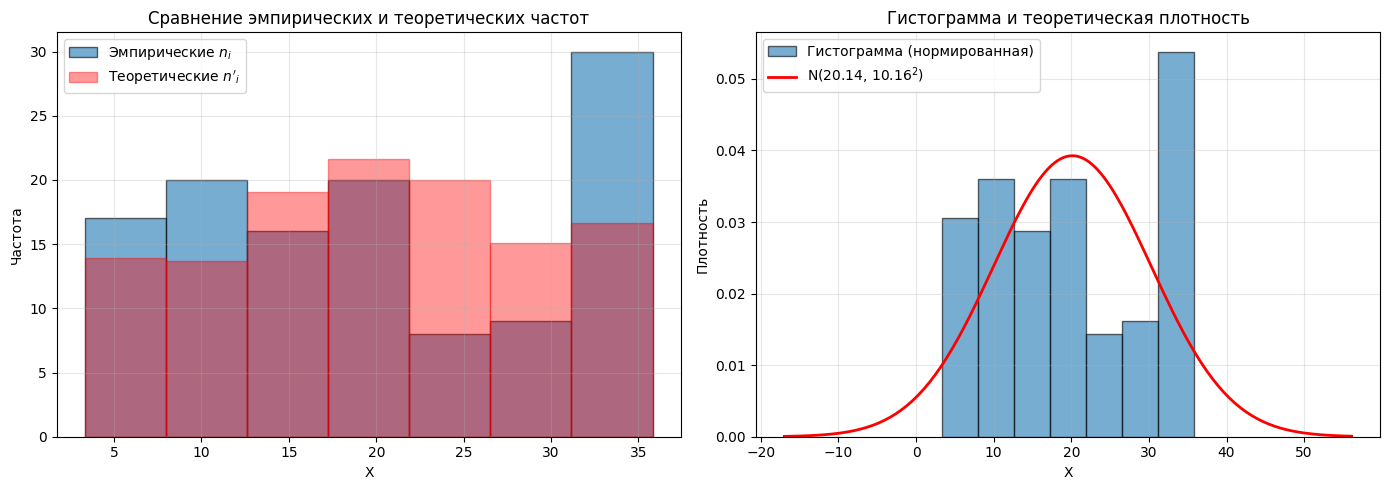

In [11]:
import matplotlib.pyplot as plt

# Гистограмма эмпирических и теоретических частот
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
ax1 = axes[0]
centers = [(edges_merged[j] + edges_merged[j+1]) / 2 for j in range(K_merged)]
widths = [edges_merged[j+1] - edges_merged[j] for j in range(K_merged)]
ax1.bar(centers, n_merged, width=widths, alpha=0.6, edgecolor='black', label='Эмпирические $n_i$')
ax1.bar(centers, np_merged, width=widths, alpha=0.4, edgecolor='red', color='red', label='Теоретические $n\'_i$')
ax1.set_xlabel('X')
ax1.set_ylabel('Частота')
ax1.set_title('Сравнение эмпирических и теоретических частот')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Плотность распределения
ax2 = axes[1]
x_plot = np.linspace(x_min - 2*S, x_max + 2*S, 200)
y_plot = stats.norm.pdf(x_plot, loc=x_mean, scale=S)
ax2.hist(data, bins=edges, density=True, alpha=0.6, edgecolor='black', label='Гистограмма (нормированная)')
ax2.plot(x_plot, y_plot, 'r-', linewidth=2, label=f'N({x_mean:.2f}, {S:.2f}$^2$)')
ax2.set_xlabel('X')
ax2.set_ylabel('Плотность')
ax2.set_title('Гистограмма и теоретическая плотность')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('chi2_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Сводная таблица результатов

In [12]:
print('=' * 60)
print('СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ')
print('=' * 60)
print(f'Объём выборки: N = {N}')
print(f'Выборочное среднее: x_в = {x_mean:.4f}')
print(f'Исправленное СКО: S = {S:.4f}')
print()

print('Доверительные интервалы для МО:')
for gamma in [0.95, 0.99]:
    alpha_two = 1 - gamma
    t_g = stats.t.ppf(1 - alpha_two / 2, df=N - 1)
    d = t_g * S / np.sqrt(N)
    print(f'  gamma={gamma}: ({x_mean - d:.4f}; {x_mean + d:.4f}), delta={d:.4f}')

print()
print('Доверительные интервалы для СКО:')
for gamma in [0.95, 0.99]:
    alpha_ci = 1 - gamma
    c_l = stats.chi2.ppf(alpha_ci / 2, df=N - 1)
    c_u = stats.chi2.ppf(1 - alpha_ci / 2, df=N - 1)
    s_l = S * np.sqrt((N - 1) / c_u)
    s_u = S * np.sqrt((N - 1) / c_l)
    print(f'  gamma={gamma}: ({s_l:.4f}; {s_u:.4f})')

print()
print(f'Критерий Пирсона (alpha = 0.05):')
print(f'  chi2_набл = {chi2_observed:.4f}')
print(f'  chi2_крит = {chi2_critical:.4f} (df = {df_chi2})')
print(f'  Гипотеза H0: {result_text}')

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
Объём выборки: N = 120
Выборочное среднее: x_в = 20.1412
Исправленное СКО: S = 10.1611

Доверительные интервалы для МО:
  gamma=0.95: (18.3046; 21.9779), delta=1.8367
  gamma=0.99: (17.7131; 22.5694), delta=2.4282

Доверительные интервалы для СКО:
  gamma=0.95: (9.0179; 11.6389)
  gamma=0.99: (8.6958; 12.1654)

Критерий Пирсона (alpha = 0.05):
  chi2_набл = 24.5504
  chi2_крит = 9.4877 (df = 4)
  Гипотеза H0: отвергается


## Выводы

1. **Доверительные интервалы для математического ожидания** построены для двух значений надёжности $\gamma = 0.95$ и $\gamma = 0.99$ при неизвестном СКО (с использованием распределения Стьюдента). При $\gamma = 0.95$ интервал: $(18.3046;\; 21.9779)$ с точностью $\delta = 1.8367$; при $\gamma = 0.99$ интервал: $(17.7131;\; 22.5694)$ с точностью $\delta = 2.4282$. При увеличении надёжности доверительный интервал расширяется, а точность оценки снижается.

2. **Доверительные интервалы для СКО** построены с использованием распределения $\chi^2$. При $\gamma = 0.95$: $(9.0179;\; 11.6389)$; при $\gamma = 0.99$: $(8.6958;\; 12.1654)$. Аналогично, при увеличении $\gamma$ интервал расширяется.

3. **Проверка гипотезы о нормальности** выполнена с помощью критерия $\chi^2$ Пирсона. Наблюдаемое значение $\chi^2_{\text{набл}} = 24.5504$ значительно превышает критическое значение $\chi^2_{\text{крит}}(0.05,\; 4) = 9.4877$. Следовательно, гипотеза $H_0$ о нормальном распределении **отвергается** на уровне значимости $\alpha = 0.05$. Распределение исследуемой случайной величины существенно отличается от нормального.

4. **Альтернативная формула** $\chi^2_{\text{набл}} = \sum \frac{n_i^2}{n'_i} - N$ доказана аналитически и подтверждена численно: оба способа вычисления дают одинаковое значение $24.5504$.

5. Выполнение работы позволило получить практические навыки построения интервальных оценок параметров распределения и проверки статистической гипотезы о нормальности с использованием критерия Пирсона. Результаты показали, что исследуемая выборка не подчиняется нормальному закону распределения.